In [ ]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
train = pd.read_csv('train.csv')    
test = pd.read_csv('test.csv')  
submission = pd.read_csv('sample_submission.csv')

* ### EDA
Om de data goed te kunnen gebruiken moet het voldoen aan wat voorwaarden zodat we het kunnen verwerken met Scikit Learn. In de onderstaande code word gekeken of er aan deze voorwaarden voldaan wordt. Zo wordt er gekeken naar of er ontbrekende of dubbele waarden zijn, of het numerieke waarden zijn en wat de form van de dataset is.

In [146]:
def VoldoetDf(df, naam):

    print(f"Analyse van DataFrame: {naam}")

    # Controleren op missende waarden
    missende_waarden = df.isnull().sum()
    if sum(missende_waarden) > 0:
            print(f'Er zijn {sum(missende_waarden)} missende waarden')
    else:
        print('Er zijn geen missende waarden')

    # Controleren op dubbele rijen
    dubbele_rijen = df.duplicated().sum()
    if dubbele_rijen > 0:
        print(f'Er zijn {dubbele_rijen} dubbele rijen')
    else:
        print('Er zijn geen dubbele rijen')

    # Controleer de datatypes van de kolommen
    data_types = df.dtypes
    print("Data types:", data_types.unique())

    # Controleer de vorm van de DataFrame
    print(f'De DataFrame heeft {df.shape[0]} rijen en {df.shape[1]} kolommen')

    # Witregel voor betere leesbaarheid
    print()
    
VoldoetDf(train, 'train')
VoldoetDf(test, 'test')
VoldoetDf(submission, 'submission')


Analyse van DataFrame: train
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 33550 rijen en 22 kolommen

Analyse van DataFrame: test
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 8388 rijen en 21 kolommen

Analyse van DataFrame: submission
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64')]
De DataFrame heeft 8388 rijen en 2 kolommen



De data voldoet aan alle eisen van Scikit Learn. Er zijn namelijk geen missende waarden, alle data is numeriek (of een boolean) en de testset en de datasets zijn tweedimensionaal. De testset en de submission set is ook even groot en zou dus geen problemen moeten opleveren.

Toon de datatypes en basisstatistieken van iedere kolom.

In [147]:
display(train.describe(), train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


None

We onderzoeken de relatie tussen onze features onderling en de relatie met onze target. Hiermee kunnen we voorkomen dat er multicollineariteit optreed in ons model. In de onderstaande cel kijken we welke features een hoge correlatie met elkaar hebben.

In [148]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")


age - ever_married_No: -0.69
age - ever_married_Yes: 0.69
age - work_type_children: -0.64
gender_Female - gender_Male: -1.00
ever_married_No - ever_married_Yes: -1.00
ever_married_No - work_type_children: 0.55
ever_married_Yes - work_type_children: -0.55
Residence_type_Rural - Residence_type_Urban: -1.00


We zien dat sommige features een perfecte correlatie hebben en dat is heel logisch. De features zijn dummy kolommen en zijn uit de kolom voortgekomen. Om dit op te lossen kunnen we simpelweg 1 van de dummy kolommen verwijderen.

In [149]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']
train = train.drop(columns=drop_columns)

Als we nu kijken welke features nog een hoge correlatie hebben zien we dat het er een stuk minder zijn.

In [150]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")

age - ever_married_Yes: 0.69
age - work_type_children: -0.64
ever_married_Yes - work_type_children: -0.55


De correlatie tussen deze features is nog niet hoog genoeg om voor multicollineariteit te zorgen, omdat daar een sterke correlatie van minstens 0.7 voor nodig is.

We zien dat de features geen grote correlatie hebben met de target. Dit betekent dat ons model naar alle features zal moeten gaan kijken om een goede voorspelling te kunnen maken.

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken.

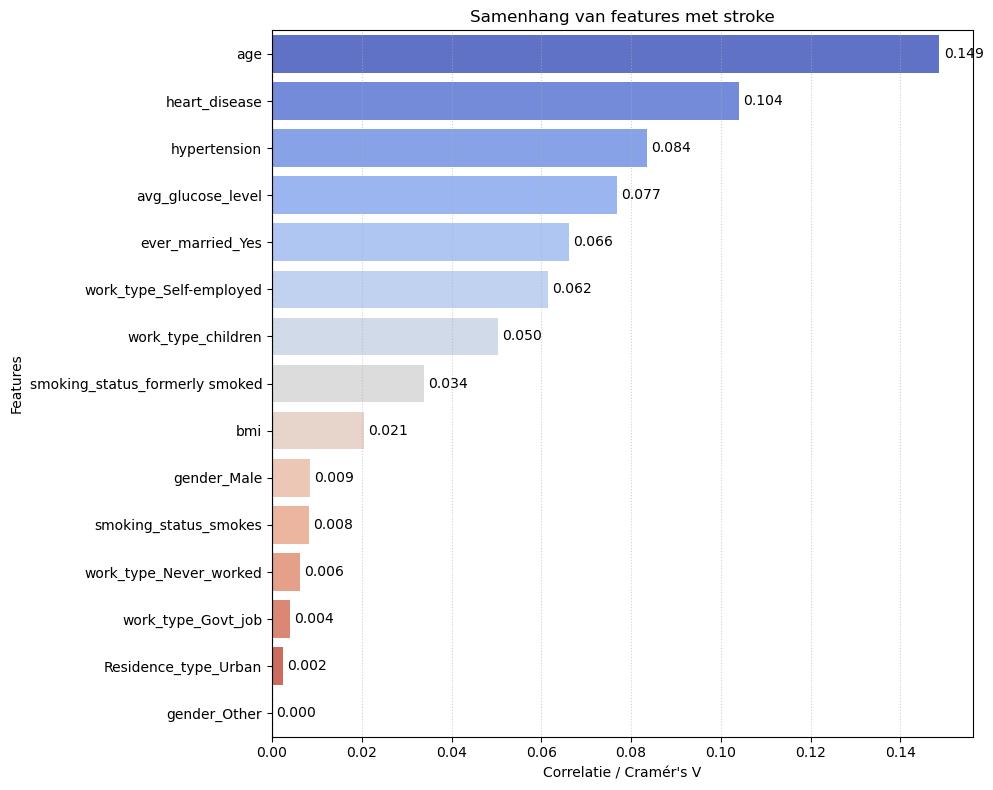

In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr, chi2_contingency


target_col = 'stroke'


# ---------------------------------------------------
# 1. Kolommen opdelen
# ---------------------------------------------------

numerical_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

categorical_cols = [
    'heart_disease',
    'hypertension',
    'ever_married_Yes',
    'work_type_Self-employed',
    'smoking_status_formerly smoked',
    'gender_Male',
    'smoking_status_smokes',
    'Residence_type_Urban',
    'gender_Other',
    'work_type_Govt_job',
    'work_type_Never_worked',
    'work_type_children'
]


# ---------------------------------------------------
# 2. Functie voor Cramér's V
# ---------------------------------------------------

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))


# ---------------------------------------------------
# 3. Point-biserial correlatie voor numerieke features
# ---------------------------------------------------

numerical_correlations = {}

for col in numerical_cols:

    # Alleen rijen gebruiken zonder missende waarden
    temp = train[[col, target_col]].dropna()

    corr, p_value = pointbiserialr(
        temp[target_col],
        temp[col]
    )

    numerical_correlations[col] = corr


# ---------------------------------------------------
# 4. Cramér's V voor categorische features
# ---------------------------------------------------

categorical_correlations = {}

for col in categorical_cols:

    temp = train[[col, target_col]].dropna()

    corr = cramers_v(
        temp[col],
        temp[target_col]
    )

    categorical_correlations[col] = corr


# ---------------------------------------------------
# 5. Alles samenvoegen
# ---------------------------------------------------

correlations = {
    **numerical_correlations,
    **categorical_correlations
}

correlations = pd.Series(correlations)

# Sorteren van hoogste naar laagste
correlations = correlations.sort_values(ascending=False)


# ---------------------------------------------------
# 6. Grafiek maken
# ---------------------------------------------------

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    legend=False,
    palette='coolwarm'
)

# Waarde achter iedere balk zetten
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )


plt.title('Samenhang van features met stroke')
plt.xlabel('Correlatie / Cramér\'s V')
plt.ylabel('Features')

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=0.8
)

plt.grid(
    axis='x',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()

In [152]:
train = train.drop(columns=["gender_Other", "id"])

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken. Gender_other heeft een correlatie van 0.000, dus deze kan weggehaald worden.

### Standardiseren
In veel gevallen ligt alle data niet op dezelfde schaal. Bijvoorbeeld in de dataset uit deze opdracht heeft een kolom zoals "heart_disease" een waarde van 0 of 1, maar age kan bijvoorbeeld 70 zijn. Bij de meeste ML modellen zal age dan veel meer invloed hebben op de voorspelling, omdat de waarde zo veel hoger ligt. Maar allebei de features hebben invloed op de voorspelling, dus wat doen we dan? In dit geval zullen wij kunnen standardiseren. Bij standardiseren worden alle features op dezelfde schaal gebracht. Als wij kijken naar de kolommen in de train- en testset, moet standardisatie zeker toegepast worden. Dit word in de code cel hieronder toegepast:

In [153]:
from sklearn.preprocessing import StandardScaler
X_train = train.drop(columns=["stroke"])
y_train = train["stroke"]
# Nieuwe scaler aanmaken
scaler = StandardScaler()

# Alleen numerieke kolommen selecteren
bool_kolommen = X_train.select_dtypes(include="bool").columns
X_train[bool_kolommen] = X_train[bool_kolommen].astype(int)
numerieke_kolommen = X_train.select_dtypes(include="number").columns

# Standardiseren en terugzetten in de dataset
X_train[numerieke_kolommen] = scaler.fit_transform(X_train[numerieke_kolommen])
display(X_train)
display(y_train)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_smokes
0,-0.525660,-0.310896,-0.212075,-0.949208,0.603791,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,2.398871
1,1.476378,3.216513,-0.212075,2.648741,2.492734,-0.821169,0.752233,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,-0.450537,-0.416863
2,-1.193007,-0.310896,-0.212075,0.750898,-1.233751,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863
3,0.230665,-0.310896,-0.212075,-0.918587,-0.051556,1.217776,0.752233,-0.376018,-0.064965,2.354796,-0.410984,0.99994,-0.450537,-0.416863
4,0.319645,-0.310896,-0.212075,2.818942,0.025544,1.217776,0.752233,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,2.219575,-0.416863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,-1.459945,-0.310896,-0.212075,0.147481,-1.811999,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,-1.00006,-0.450537,-0.416863
33546,0.230665,-0.310896,-0.212075,-0.355524,0.282543,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
33547,-1.726883,-0.310896,-0.212075,-0.330125,-1.593550,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,-1.00006,-0.450537,-0.416863
33548,0.631073,3.216513,-0.212075,-0.501987,-0.102956,-0.821169,0.752233,2.659448,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871


0        0
1        0
2        0
3        0
4        0
        ..
33545    0
33546    0
33547    0
33548    0
33549    0
Name: stroke, Length: 33550, dtype: int64

# 2
### Metrics
Metrics zijn bepaalde functies die je gebruikt om de prestatie van je model na het trainen, te beoordelen. Dit word gedaan op de testset. In deze dataset moeten wij een klasse voorspellen **(0 is geen stroke, 1 is gelijk aan stroke)**. De metrics die wij kunnen gebruiken zijn:

**Accuracy:** Hoeveel van de voorspellingen zijn juist voorspeld door het model?

**Recall:** Hoeveel van de positieve klassen worden teruggevonden door het model?

**Precision:** Als het model een positieve klasse voorspelt, hoe vaak is dit juist?

**F1-score:** Een combinatie tussen Recall en Precision




### test set klaarmaken:

In [154]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']
test = test.drop(columns=drop_columns)
test = test.drop(columns=["gender_Other", "id"])
X_test = test
y_test = submission.drop(columns=["id"])
bool_kolommen = X_test.select_dtypes(include="bool").columns
X_test[bool_kolommen] = X_test[bool_kolommen].astype(int)
numerieke_kolommen = X_test.select_dtypes(include="number").columns
X_test[numerieke_kolommen] = scaler.transform(X_test[numerieke_kolommen])
display(X_test)
display(y_test)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_smokes
0,0.453114,-0.310896,-0.212075,-0.148767,-0.873953,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871
1,-0.525660,-0.310896,-0.212075,2.953061,2.454184,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871
2,-0.703619,-0.310896,-0.212075,0.230089,-0.539854,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
3,-0.792599,-0.310896,-0.212075,-0.580084,-0.976752,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,2.219575,-0.416863
4,0.942501,-0.310896,-0.212075,-0.329887,0.603791,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8383,-0.792599,-0.310896,-0.212075,-0.618302,-0.462754,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863
8384,-1.104027,-0.310896,-0.212075,-0.085387,-0.758303,-0.821169,-1.329375,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,-0.450537,-0.416863
8385,-1.370965,-0.310896,-0.212075,-0.557296,-0.822553,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,0.99994,-0.450537,-0.416863
8386,-1.148517,-0.310896,-0.212075,0.039712,2.428484,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863


,stroke
0,1
1,0
2,1
3,0
4,1
...,...
8383,0
8384,0
8385,1
8386,0


### Uitvoeren model:

In [157]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SVC model
svc_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",  # handig als je binaire klassen ongelijk verdeeld zijn
    random_state=42
)

# Model trainen
svc_model.fit(X_train, y_train)

# Voorspellingen
y_pred = svc_model.predict(X_test)

# Evaluatie
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5021459227467812

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.80      0.62      4241
           1       0.49      0.20      0.28      4147

    accuracy                           0.50      8388
   macro avg       0.50      0.50      0.45      8388
weighted avg       0.50      0.50      0.45      8388


Confusion Matrix:
[[3380  861]
 [3315  832]]


## Confusion Matrix

|                      | Voorspeld positief | Voorspeld negatief |
|----------------------|--------------------:|--------------------:|
| **Werkelijk positief** | TP = True Positive | FN = False Negative |
| **Werkelijk negatief** | FP = False Positive | TN = True Negative |

## Metrics op basis van de Confusion Matrix

| Metric | Formule | Betekenis |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Hoeveel % van de voorspellingen zijn juist voorspeld door het model? |
| **Recall** | $\frac{TP}{TP + FN}$ | Hoeveel % van de positieve klassen worden teruggevonden door het model? |
| **Precision** | $\frac{TP}{TP + FP}$ | Van alle positieve voorspelde gevallen: hoeveel % zijn echt positief? |
| **F1-score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Een combinatie tussen Recall en Precision |

### Waarom F1-score bij dit vraagstuk?

De beste manier om dit uit te leggen, is omdat het mogelijk is om bij elk andere metric het model te optimaliseren om het heel goed op deze metric, en alleen op deze metric het goed te doen. Bij een Kaggle-wedstrijd zou je in principe bij elke Metric behalve F1-score "vals" kunnen spelen om een perfecte score te krijgen en de wedstrijd te winnen. Maar dan hoef je niet een goed model te ontwikkelen maar alleen op een metric goed te presteren.

**Accuracy:** *Kan niet.* In het geval van een imbalanced dataset zoals deze, zal het model (bijna) altijd negatief kunnen voorspellen en alsnog een bijna perfecte score te krijgen, terwijl het de belangrijkste gevallen niet kan voorspellen.

**Recall:** *Kan niet.* Het model zal (bijna) altijd positief kunnen voorspellen en dan zal het model alle strokes terug kunnen vinden. De metric is dan perfect, maar het model is waardeloos.

**Precision:** *Kan niet.* Het model zal (bijna) altijd negatief kunnen voorspellen maar alleen bij *HELE zekere* gevallen positief kunnen voorspellen. Dan zijn alle positieve voorspellingen juist, maar het model zal dan bijna nooit een voorspelling maken tenzij het heel zeker is.

**F1-Score:** *Kan wel.* Het is een combinatie tussen Precision en Recall. Om een perfecte score te krijgen voor Recall moet je altijd positief voorspellen, bij precision moet je juist bijna nooit positief voorspellen. Dit betekent dat om voor allebei deze metrics tegelijkertijd een perfecte score te krijgen, onmogelijk is. De formule voor de F1-score is ook zo opgesteld dat een hele lage score voor één van de twee metrics de F1-score sterk naar beneden trekt. Als je het model bijvoorbeeld optimaliseert voor de Recall door alleen positief te voorspellen (score van 1 voor de recall), maar de Precision is bijna 0 is, dan zal de F1-score alsnog bijna 0 zijn, dan maakt het niet uit hoe hoog de Recall is zo lang de Precision laag is. 

*De F1-score is de enige metric waarbij niet vals gespeeld kan worden om je model er "perfect" uit te laten zien.*
